Loading Dataset...

First 5 Rows


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price,Rooms_per_House
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0.166289
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0.283552
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0.156380
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0.109761
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0.118526


Dataset Shape: (20640, 10)

Missing Values


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0
Rooms_per_House,0



Statistics


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price,Rooms_per_House
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558,0.257232
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956,0.290724
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990,0.018003
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000,0.124499
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000,0.173675
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250,0.286211
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010,10.062500


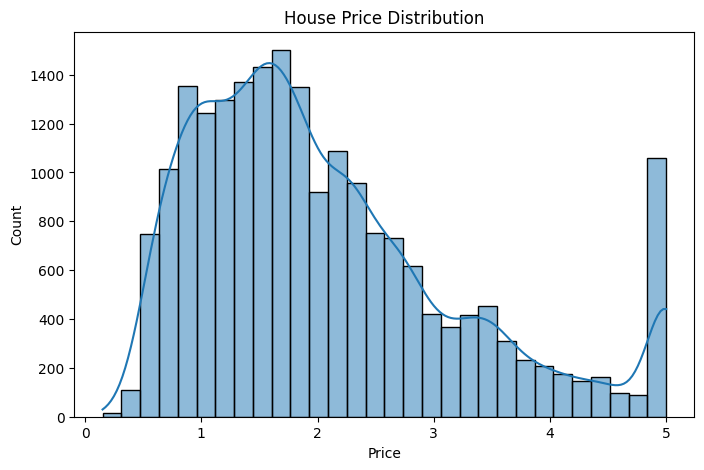

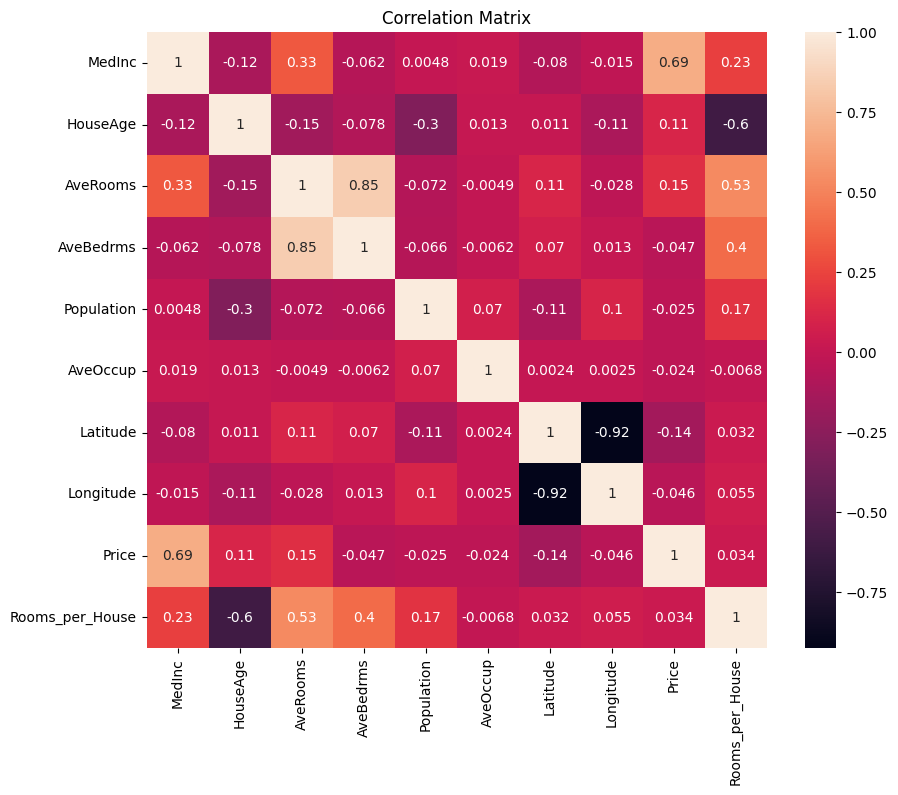


MODEL PERFORMANCE
MAE : 0.533
RMSE : 0.745
R2 Score : 0.577

Prediction Comparison


,Actual,Predicted,Difference
0,0.47700,0.715422,-0.238422
1,0.45800,1.760966,-1.302966
2,5.00001,2.720211,2.279799
3,2.18600,2.832940,-0.646940
4,2.78000,2.602816,0.177184
5,1.58700,2.008370,-0.421370
6,1.98200,2.643026,-0.661026
7,1.57500,2.169376,-0.594376
8,3.40000,2.759374,0.640626
9,4.46600,3.915312,0.550688



Feature Contribution


,Feature,Coefficient
3,AveBedrms,0.783781
0,MedInc,0.448532
8,Rooms_per_House,0.056851
1,HouseAge,0.010398
4,Population,-0.000003
5,AveOccup,-0.003523
2,AveRooms,-0.126611
6,Latitude,-0.419867
7,Longitude,-0.433851


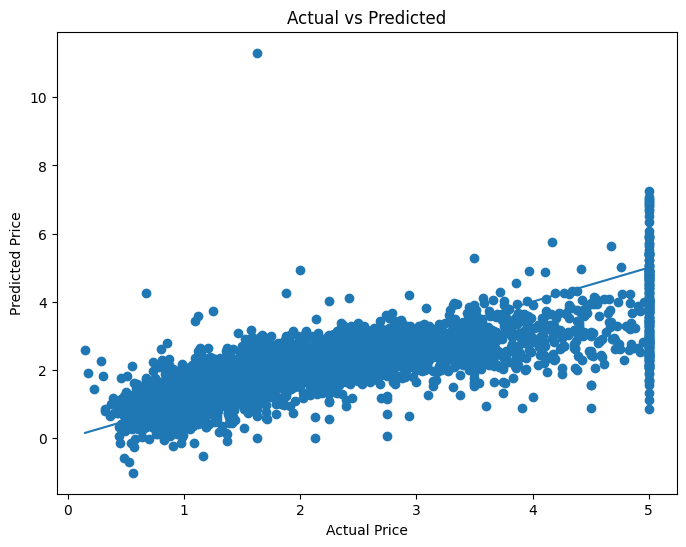


Task Completed Successfully


In [2]:
# ==========================================
# AI & ML TASK 1
# House Price Prediction using Linear Regression
# California Housing Dataset
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Loading Dataset...\n")

# Load Dataset
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

# Feature Engineering
df["Rooms_per_House"] = (
    df["AveRooms"]
    /
    (df["HouseAge"] + 1)
)

# Preview
print("First 5 Rows")
display(df.head())

# Dataset Summary
print("Dataset Shape:", df.shape)

print("\nMissing Values")
display(df.isnull().sum())

print("\nStatistics")
display(df.describe())

# -------------------
# Visualization
# -------------------

plt.figure(figsize=(8,5))

sns.histplot(
    df["Price"],
    bins=30,
    kde=True
)

plt.title("House Price Distribution")
plt.show()

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

# -------------------
# Prepare Data
# -------------------

X = df.drop(
    "Price",
    axis=1
)

y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# -------------------
# Train Model
# -------------------

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

# Prediction
predictions = model.predict(
    X_test
)

# -------------------
# Evaluation
# -------------------

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\nMODEL PERFORMANCE")
print("MAE :", round(mae,3))
print("RMSE :", round(rmse,3))
print("R2 Score :", round(r2,3))

# -------------------
# Compare Output
# -------------------

result = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": predictions[:10]
})

result["Difference"] = (
    result["Actual"]
    -
    result["Predicted"]
)

print("\nPrediction Comparison")
display(result)

# -------------------
# Feature Importance
# -------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nFeature Contribution")
display(importance)

# -------------------
# Final Graph
# -------------------

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.plot(
[
y_test.min(),
y_test.max()
],
[
y_test.min(),
y_test.max()
]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
"Actual vs Predicted"
)

plt.show()

print("\nTask Completed Successfully")